In [125]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) #ensure reproducibility

### Visualizing Data

In [126]:
#import the data
df = pd.read_csv("4H03 Data.csv")

#ignore the subject column for this study
data = df.drop(columns = ['subject'])

#check for nulls
data.isnull().any()

message    False
label      False
dtype: bool

In [127]:
#summary of spam and non-spam emails
#Spam is 1 and Non-Spam is 0
data.groupby('label').describe()

message                                                               
        count unique                                                top freq
label                                                                       
0        2412   2401  names , the journal of the american name socie...    2
1         481    458  this is not spam ; you are receiving this mess...    5

Text(0.5, 1.0, 'Distribution of Spam vs Non-Spam')

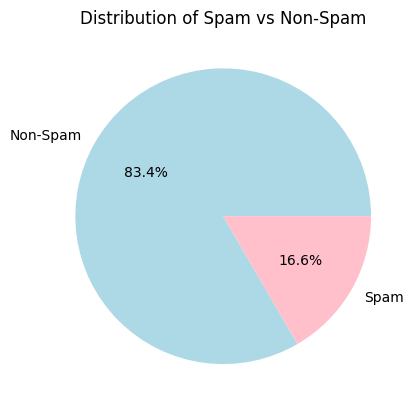

In [128]:
#visualizing data
count = data['label'].value_counts()
plt.pie(count, autopct='%1.1f%%', labels = ["Non-Spam", "Spam"], colors = ["lightblue","pink"])
plt.title(f'Distribution of Spam vs Non-Spam')

### Preprocessing

In [129]:
#import stopwords from stopwords dataset
#https://www.kaggle.com/datasets/amirhoseinsedaghati/english-stopwords
with open('EN-Stopwords.txt') as stop:
    stopwords = [w.strip() for w in stop]

In [130]:
#importing suffix table generated by Claude
suffix_table = pd.read_csv('suffix_table_sorted.csv')
suffix = [s.strip('-') for s in suffix_table['Suffix']] #return list of suffix without '-'
replacement = suffix_table['Replacement'].fillna("").tolist() #return list of replacement without NaN

#stemming function
def stemming(text):
    for i in range(len(suffix)):
        if text.endswith(suffix[i]): #check if text ends with a suffix
            root = text[:len(text) - len(suffix[i])] + replacement[i] #if yes, extract root word and add replacement
            
            if len(root) >= 3 and root[-1] == root[-2]: #remove duplicate character like in running
                root = root[:-1]

            if len(root) >= 3: #avoid over-stemming
                return root
    
    return text #return orginal text if already in root format

### Extracting and Splitting Data

In [131]:
#creating a balance training set to prevent biased prediction
spam = data[data['label'] == 1]
non_spam = data[data['label'] == 0]

#training data
train_spam = spam.sample(300, random_state=42)
train_nonspam = non_spam.sample(300, random_state=42)
train = pd.concat([train_spam, train_nonspam])

#testing data
test_spam = spam.drop(train_spam.index)
new_nonspam = non_spam.drop(train_nonspam.index)
test_nonspam = new_nonspam.sample(400 - len(test_spam), random_state=42)
test = pd.concat([test_spam, test_nonspam])

#reset indices for indexing later on
train = train.reset_index(drop = True)
test = test.reset_index(drop = True)

#set data
dataset = pd.concat([train, test])
dataset = dataset.reset_index(drop = True)

#splitting data
x_train, y_train = train['message'], train['label']
x_test, y_test = test['message'], test['label']

In [132]:
#import contractions
#preprocessing function
def preprocessing(text):
    #text = text.lower() #prevent case sensitivity
    #text = re.sub(r'[^a-zA-Z]', ' ', text) #remove special characters
    #text = contractions.fix(text) #normalizing words e.g. don't to do not
    token = text.split() #split string into individual words
    remove = [w for w in token if w not in stopwords] #remove stopwords
    processed = [stemming(w) for w in remove] #stemming

    return ' '.join(processed)

#preprocessing data
train['message'] = train['message'].apply(preprocessing)
test['message'] = test['message'].apply(preprocessing)
dataset['message'] = dataset['message'].apply(preprocessing)

In [133]:
#split new data into spam and non-spam 
spam_train = train[train['label'] == 1]['message']
nspam_train = train[train['label'] == 0]['message']

### Extracting Vocabulary

In [134]:
def wordcount(email):
    count = 0
    for i in range(len(email)):
        for v in email.iloc[i].split():
            count += 1
    return count

s_count = wordcount(spam_train)
ns_count = wordcount(nspam_train)

In [135]:
#get all unique words/vocabulary/features and the frequency
#https://www.youtube.com/watch?v=hOuvYcw_sVQ&t=662s
def vocab(data):
    vocab = {}
    for email in data['message']:
        words = email.split()
        for w in words:
            if w in vocab:
                vocab[w] += 1
            else:
                vocab[w] = 1
    return vocab

total_vocab = vocab(train)

In [136]:
#match vocab with index
#https://www.youtube.com/watch?v=hOuvYcw_sVQ&t=662s
vocab_ind = {t:i for t,i in zip(total_vocab, range(len(total_vocab)))}

In [137]:
#count the number of times a word in vocab appear in spam/non-spam email
#code output from Claude to help reducing computational time from original code
def vocab_count(emails):
    vocab_count = {w: 0 for w in total_vocab}

    for email in emails:
        words = email.split()
        for w in words:
            if w in vocab_count:
                vocab_count[w] += 1

    return vocab_count

s_vocabcount = vocab_count(spam_train)
ns_vocabcount = vocab_count(nspam_train)

### Fitting Naive Bayes

In [138]:
#calculate prior probability
s_prior = len(spam_train)/len(train)
ns_prior = len(nspam_train)/len(train)

In [ ]:
#calculate conditional probability
def cond_prob(totalwords, wordcount, vocabcount):
    cond_prob = {}
    for w in totalwords:
        cond_prob[w] = (vocabcount[w] + 1)/(wordcount + len(totalwords))
    return cond_prob

s_cond = cond_prob(total_vocab, s_count, s_vocabcount)
ns_cond = cond_prob(total_vocab, ns_count, ns_vocabcount)

In [140]:
#classifier for prediction
#log was used based on this https://cs.mcgill.ca/~wlh/comp451/files/comp451_chap5.pdf
def NB_classifier(email):
    s_posterior = np.log(s_prior)
    ns_posterior = np.log(ns_prior)
    
    for w in email.split():
        if w in total_vocab:    
            s_posterior += np.log(s_cond[w])
            ns_posterior += np.log(ns_cond[w])
    
    if s_posterior - ns_posterior > 0:
        return 1
    else:
        return 0

In [141]:
TP, TN, FP, FN  = 0,0,0,0
for i in range(len(y_test)):
    if y_test[i] == 0:
        if NB_classifier(x_test[i]) == 0:
            TN += 1
        else:
            FP += 1
    else: 
        if NB_classifier(x_test[i]) == 0:
            FN += 1
        else:
            TP += 1

P = TP/(TP + FP)
R = TP/(TP + FN)
F = 2*P*R/(P+R)
A = (TP + TN)/(TP + TN + FP + FN)
print(f'Precision: {P*100:.2f}%')
print(f'Recall: {R*100:.2f}%')
print(f'F-Measure: {F*100:.2f}%')
print(f'Accuracy: {A*100:.2f}%')

Precision: 93.58%
Recall: 96.69%
F-Measure: 95.11%
Accuracy: 95.50%
